In [1]:
using Revise
includet("../../cluster_env/runs/si_disprel2/base.jl")

In [2]:
using ProgressMeter
using ColorSchemes
using UnPack

In [3]:
includet("../../scripts/figures_util.jl")

using GLMakie
using CairoMakie
CairoMakie.activate!()

# Process data and do MM fits

In [ ]:
dirpath = "../../cluster_env/runs/si_disprel2/main5_pd_cov1/"
adf, prparams = process_outdir1(dirpath, 10 .^ range(-5, 5, 1000), 0., 1e-12;
    out_fname="../../cluster_env/runs/si_disprel2/main5_processed1.jld2"
);

Reading 600 files
Files have nrow(adf) = 60000 runsKeeping 39318 of them after filtering for successful solves, small maxresids, hss stability and non-extinctions

Progress:  80%|████████████████████████████████▊        |  ETA: 0:01:13

In [55]:
f = jldopen("../../cluster_env/runs/si_disprel2/processed.jld2")
adf = f["adf"];
prparams = f["processing_params"];

In [56]:
ks = prparams.ks;

In [57]:
adf = @subset adf (!ismissing).(:fit_d) :mm_h .> 0.;

# d dist

Excluding 260 fit ds of 18182 which are above 1.5

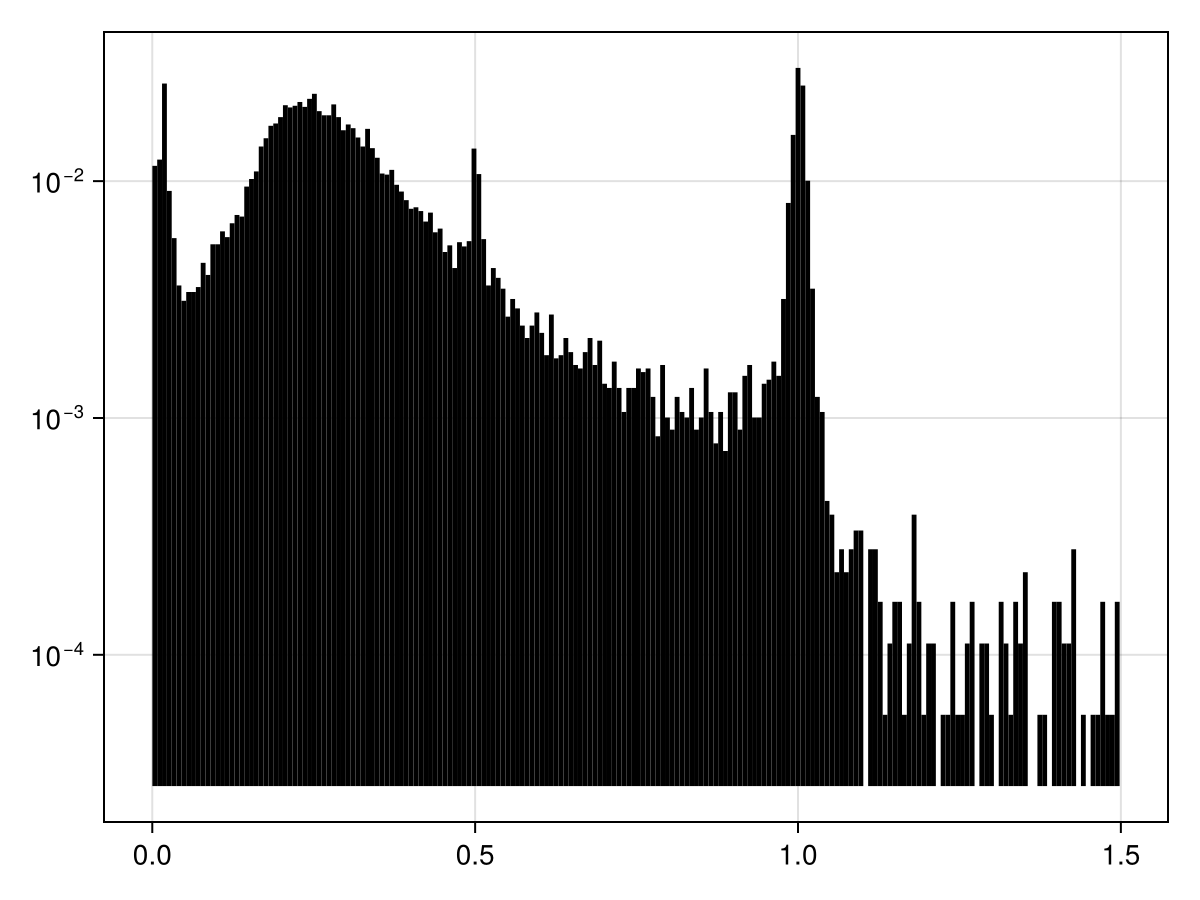

In [119]:
# hist(adf.fit_d; axis=(; yscale=log10))
d_cutoff = 1.5
@printf "Excluding %d fit ds of %d which are above %.3g" count(>(d_cutoff), adf.fit_d) nrow(adf) d_cutoff
fap = hist(filter(<(d_cutoff), adf.fit_d);
    bins=200,
    normalization=:probability,
    color=:black,
    axis=(; yscale=log10),
)
# display(GLMakie.Screen(), fap)
fap

# Example disprel fits

linthresh = 0.0001

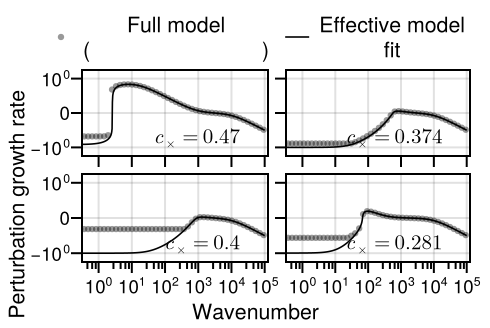

In [88]:
seed = 57
example_is = sort(randperm(Xoshiro(seed), nrow(adf))[1:4])

ydepth = 3. # decades of log range below the tallest peak - this sets linthresh
yup = 5.   # top of the axis, in decades above linthresh
ydown = 5. # bottom of the axis, in decades below -linthresh

# the SI disprel is sampled on all 1000 ks, which is far denser than the panel can
# resolve as markers - show every sistride'th one
sistride = 12
si_kwargs = (; color=(:black, 0.4), markersize=4.5)
mm_kwargs = (; color=:black, linewidth=0.8)

# one y scale shared by all four panels, anchored on the tallest peak of the four,
# so peak heights can be compared across panels
peak = maximum(example_is) do i
    max(maximum(adf[i, :si_mrls]), maximum(adf[i, :mmls]))
end
linthresh = 10. ^ (floor(log10(peak)) - ydepth)
# linthresh = 1.
@show linthresh

yticksfn = CustomSymlogScale.ticks(linthresh; max_ticks=4, trim=1e0)
# yticksfn = CustomSymlogScale.ticks([-100,-10,-1,1,10,100])
ylo, yhi = -linthresh * 10^ydown, linthresh * 10^yup

fig = Figure(;
    # size=(double_col_width * 0.48, 0.55 * double_col_width / golden_ratio),
    size=(double_col_width * 0.36, 0.39 * double_col_width / golden_ratio),
    figure_padding=(2., 10., 2., 6.),
)

axs = Axis[]
for (n, i) in enumerate(example_is)
    r = adf[i, :]
    row, col = fldmod1(n, 2)

    kks, si_mrls, mmls = ks, r.si_mrls, r.mmls

    ax = Axis(fig[row, col];
        xscale=log10,
        CustomSymlogScale.kwargs(linthresh; max_ticks=5, nminor=0)...,
        yticks=yticksfn,
        xticks=log10ticks(0:5),
        xminorticksvisible=true,
        xminorticks=IntervalsBetween(5),
        xticklabelsize=7fontsize_pt,
        yticklabelsize=7fontsize_pt,
        xticklabelpad=0.,
        yticklabelpad=0.,
    )

    scatter!(ax, kks[1:sistride:end], si_mrls[1:sistride:end]; si_kwargs...)
    lines!(ax, kks, mmls; mm_kwargs...)

    text!(ax, 0.85, 0.07;
        text=latexstring(@sprintf "c_\\times=%.3g" r.fit_d),
        space=:relative,
        align=(:right, :bottom),
        justification=:right,
        fontsize=7fontsize_ltex_pt,
    )

    # xlims!(ax, extrema(kks)...)
    xlims!(ax, 10^-0.5, 10^5.1)
    ylims!(ax, ylo, yhi)

    # both scales are shared, so only label each one once
    col == 2 && hideydecorations!(ax; ticks=false, grid=false)
    row == 1 && hidexdecorations!(ax; ticks=false, grid=false)
    push!(axs, ax)
end
linkaxes!(axs...)

Label(fig[1:2, 0], "Perturbation growth rate             ";
    fontsize=8fontsize_pt,
    rotation=pi/2,
    padding=(0., 2., 0., 0.),
)
Label(fig[3, 1:2], "Wavenumber       ";
    fontsize=8fontsize_pt,
    padding=(0., 0., 0., 2.),
)
Legend(fig[0, 0:2],
    [MarkerElement(; marker=:circle, si_kwargs...), LineElement(; mm_kwargs...)],
    ["Full model\n(                             )", "Effective model\nfit"];
    orientation=:horizontal,
    labeljustification=:center,
    labelsize=8fontsize_pt,
    framevisible=false,
    padding=(20., 0., 0., 0.),
    patchsize=(12., 6.),
    colgap=8.,
)

rowgap!(fig.layout, 4.)
colgap!(fig.layout, 4.)
colgap!(fig.layout, 1, 0.)
rowgap!(fig.layout, 1, 4.) # legend to panels
rowgap!(fig.layout, 3, 0.) # panels to x label

# Makie.save("../../figures2/fig2/disprel_examples.pdf", fig)

fig


# Peak fitting stats (OLD, has both)

mdh = maximum(deltah) = -0.00041102928211929514
count((>)(mdh - 1), deltah) = 35

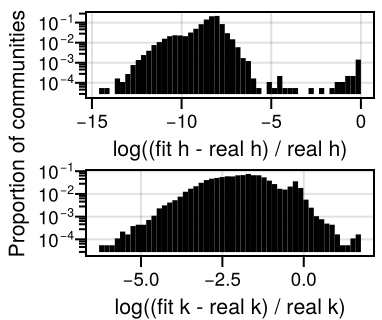

In [91]:
deltak = log10.(abs.(adf.mm_k .- adf.si_k) ./ adf.si_k)
deltah = log10.(abs.(adf.mm_h .- adf.si_h) ./ adf.si_h)

@show mdh = maximum(deltah)
@show count(>(mdh - 1), deltah)

fig = Figure(;
    size=(double_col_width * 0.28, 0.38 * double_col_width / golden_ratio),
    figure_padding=(2., 4., 2., 6.),
)
ax_kwargs = (;
    yscale=log10,
    xlabelsize=8fontsize_pt,
    xlabelpadding=2.,
    xticklabelsize=7fontsize_pt,
    yticklabelsize=7fontsize_pt,
    xticklabelpad=0.,
    yticklabelpad=0.,
    yminorticksvisible=true,
    yminorticks=IntervalsBetween(5),
)
ax1 = Axis(fig[1, 1];
    xlabel="log((fit h - real h) / real h)",
    ax_kwargs...,
)
ax2 = Axis(fig[2, 1];
    xlabel="log((fit k - real k) / real k)",
    ax_kwargs...,
)
hist!(ax1, deltah;
    bins=50,
    color=:black,
    normalization=:probability,
)
hist!(ax2, deltak;
    bins=50,
    color=:black,
    normalization=:probability,
)
Label(fig[:,0], "Proportion of communities";
    fontsize=8fontsize_pt,
    rotation=pi/2,
)

rowgap!(fig.layout, 6.)
colgap!(fig.layout, 6.)

Makie.save("../../figures2/fig2/fit_metrics.pdf", fig)

fig

count((>)(hcut), abs.(deltah)) = 0
count((>)(kcut), abs.(deltak)) = 0
(count(.!(inliers)), length(inliers)) = (0, 18182)

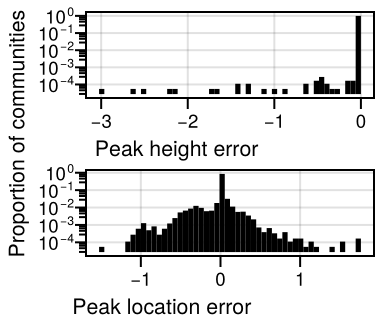

In [81]:
kcut, hcut = Inf, Inf
# kcut, hcut = Inf, 1e-6

deltak = log10.(adf.mm_k ./ adf.si_k)
deltah = log10.(adf.mm_h ./ adf.si_h);

@show count(>((hcut)), abs.(deltah))
@show count(>((kcut)), abs.(deltak))

inliers = (abs.(deltak) .<= kcut) .& (abs.(deltah) .<= hcut)
@show count(.!inliers), length(inliers)
deltak, deltah = deltak[inliers], deltah[inliers]

fig = Figure(;
    size=(double_col_width * 0.28, 0.38 * double_col_width / golden_ratio),
    figure_padding=(2., 4., 2., 6.),
)
ax_kwargs = (;
    yscale=log10,
    xlabelsize=8fontsize_pt,
    xlabelpadding=2.,
    xticklabelsize=7fontsize_pt,
    yticklabelsize=7fontsize_pt,
    xticklabelpad=0.,
    yticklabelpad=0.,
    yminorticksvisible=true,
    yminorticks=IntervalsBetween(5),
)
ax1 = Axis(fig[1, 1];
    xlabel="Peak height error                  ",
    ax_kwargs...,
)
ax2 = Axis(fig[2, 1];
    xlabel="Peak location error                       ",
    ax_kwargs...,
)
hist!(ax1, deltah;
    bins=50,
    color=:black,
    normalization=:probability,
)
hist!(ax2, deltak;
    bins=50,
    color=:black,
    normalization=:probability,
)
Label(fig[:,0], "Proportion of communities";
    fontsize=8fontsize_pt,
    rotation=pi/2,
)

rowgap!(fig.layout, 6.)
colgap!(fig.layout, 6.)

Makie.save("../../figures2/fig2/fit_metrics.pdf", fig)

fig